In [2]:
# Imports and open the file
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import ndimage
from aislens.config import config
import cftime
import geopandas as gpd
import matplotlib.path as mpath

# Path to file (expects DIR_PROCESSED variable defined earlier in the environment/notebook)
try:
    config.DIR_PROCESSED  # ensure variable exists
except NameError:
    raise RuntimeError(
        "DIR_PROCESSED is not defined. Please set DIR_PROCESSED to the processed data folder and re-run this cell."
    )
nc_path = os.path.join(config.DIR_PROCESSED, 'sorrm_seasonality.nc')
if not os.path.exists(nc_path):
    raise RuntimeError(f'File not found: {nc_path}')

print('Reading:', nc_path)
ds = xr.open_dataset(nc_path, chunks={config.TIME_DIM: 36})
# Use the first data variable by default (change varname if required)
varname = list(ds.data_vars)[0]
print('Using variable:', varname)
arr = ds[varname].values  # expected shape: (time, y, x) or (time, lat, lon)
print('Array shape:', arr.shape)

# Extract first n time slices from ds
n_times = 48
# slice carefully using the named time dimension
if config.TIME_DIM in ds.dims:
    ds = ds.isel({config.TIME_DIM: slice(0, n_times)})
else:
    ds = ds.isel({list(ds.dims)[0]: slice(0, n_times)})

# Coarsen factor for quick prototyping (integer >= 1). We will keep at 1 by default.
coarsen = 1  # change to >1 only if you understand the aliasing consequences


Reading: /Users/smurugan9/research/aislens/AISLENS/data/processed/sorrm_seasonality.nc
Using variable: __xarray_dataarray_variable__
Using variable: __xarray_dataarray_variable__
Array shape: (3600, 601, 601)
Array shape: (3600, 601, 601)


In [3]:
# Mask + CRS + rasterization diagnostic (paste & run)
import os
import numpy as np
import geopandas as gpd
import matplotlib.path as mpath
from shapely.geometry import mapping

# Optionally set this before running if you have a specific file
MASK_GEOJSON = '/Users/smurugan9/research/aislens/AISLENS/data/external/iceShelves.geojson'

#MASK_GEOJSON = globals().get('MASK_GEOJSON', None)
candidates = []
if MASK_GEOJSON:
    candidates.append(MASK_GEOJSON)
candidates.extend([
    os.path.join('data', 'external', 'iceShelves.geojson'),
    os.path.join(config.DIR_PROCESSED, 'iceShelves.geojson') if hasattr(config, 'DIR_PROCESSED') else None,
])
candidates = [p for p in candidates if p is not None]

print("Mask candidate paths and existence:")
for p in candidates:
    print(" ", p, "exists=", os.path.exists(p))

# pick first existing
mask_path = next((p for p in candidates if os.path.exists(p)), None)
if mask_path is None:
    raise FileNotFoundError("No mask file found. Set MASK_GEOJSON to the correct path and re-run this cell.")

print("Using mask file:", mask_path)
icems = gpd.read_file(mask_path)
print("Loaded icems; features:", len(icems))
print("icems.crs:", icems.crs)

# Prepare a data sample (first time slice)
time_dim = config.TIME_DIM if config.TIME_DIM in ds.dims else list(ds.dims)[0]
da_test = ds[varname].isel({time_dim: 0})
print("da_test dims/shape:", da_test.dims, tuple(da_test.shape))

# Try reading data CRS via rioxarray if available
data_crs = None
try:
    data_crs = da_test.rio.crs
    print("Data CRS (da_test.rio.crs):", data_crs)
except Exception as e:
    print("Could not read data CRS via rioxarray:", e)

# If both CRSs exist and differ, reproject icems
if (getattr(icems, "crs", None) is not None) and (data_crs is not None) and (icems.crs != data_crs):
    print("Reprojecting icems from", icems.crs, "to", data_crs)
    try:
        icems = icems.to_crs(data_crs)
        print("Reprojection succeeded; new icems.crs:", icems.crs)
    except Exception as e:
        print("Reprojection failed:", e)

# Try rasterize with rasterio if available
mask_arr = None
try:
    from rasterio.features import rasterize
    transform = da_test.rio.transform()
    out_shape = tuple(da_test.shape)
    geoms = [(mapping(g), 1) for g in icems.geometry if g is not None]
    if len(geoms) == 0:
        print("No geometries in icems to rasterize.")
    else:
        mask_arr = rasterize(geoms, out_shape=out_shape, transform=transform, fill=0, dtype='uint8')
        print("Rasterize succeeded; mask sum =", int(mask_arr.sum()))
except Exception as e:
    print("Rasterio rasterize not used/failed:", e)

# Fallback: polygon containment on grid coordinates
if mask_arr is None:
    print("Falling back to polygon containment rasterization (may be slower).")
    # get spatial dims names and coords
    y_dim, x_dim = da_test.dims[-2], da_test.dims[-1]
    x_coords = np.asarray(da_test.coords[x_dim].values)
    y_coords = np.asarray(da_test.coords[y_dim].values)
    # build point grid (flattened)
    X, Y = np.meshgrid(x_coords, y_coords)
    pts = np.vstack((X.ravel(), Y.ravel())).T
    mask_bool = np.zeros((len(y_coords), len(x_coords)), dtype=bool)
    for gi, geom in enumerate(icems.geometry):
        if geom is None:
            continue
        try:
            # handle MultiPolygon/Polygon uniformly
            polys = [geom] if geom.geom_type == 'Polygon' else list(geom)
        except Exception:
            polys = [geom]
        for poly in polys:
            try:
                exterior = np.array(poly.exterior.coords)
                path = mpath.Path(exterior)
                contained = path.contains_points(pts).reshape(len(y_coords), len(x_coords))
                # subtract holes if present
                for interior in getattr(poly, "interiors", []):
                    hole_path = mpath.Path(np.array(interior.coords))
                    hole_mask = hole_path.contains_points(pts).reshape(len(y_coords), len(x_coords))
                    contained = contained & (~hole_mask)
                mask_bool |= contained
            except Exception as e:
                # skip malformed polygon
                continue
    mask_arr = mask_bool.astype('uint8')
    print("Fallback rasterization mask sum =", int(mask_arr.sum()))

# Basic overlap diagnostics
arr = ds[varname].values  # (time, y, x)
print("Dataset shape:", arr.shape)
total_nans = int(np.count_nonzero(np.isnan(arr)))
total_finite = int(np.count_nonzero(np.isfinite(arr)))
print("Total NaNs:", total_nans, "Total finite:", total_finite)

# Check how many finite values fall inside rasterized mask (spatially)
# collapse time axis and test spatial finite presence
spatial_finite = np.any(np.isfinite(arr), axis=0)
if mask_arr is not None:
    try:
        mask_bool = mask_arr.astype(bool)
        # ensure mask shape matches spatial dims
        if mask_bool.shape != spatial_finite.shape:
            print("Warning: mask shape", mask_bool.shape, "!= data spatial shape", spatial_finite.shape)
        overlap_count = int(np.count_nonzero(np.logical_and(mask_bool, spatial_finite)))
        print("Spatial finite points inside mask:", overlap_count, "of", int(np.count_nonzero(mask_bool)))
    except Exception as e:
        print("Failed overlap check:", e)

print("Diagnostic finished.")

Mask candidate paths and existence:
  /Users/smurugan9/research/aislens/AISLENS/data/external/iceShelves.geojson exists= True
  data/external/iceShelves.geojson exists= False
  /Users/smurugan9/research/aislens/AISLENS/data/processed/iceShelves.geojson exists= False
Using mask file: /Users/smurugan9/research/aislens/AISLENS/data/external/iceShelves.geojson
Loaded icems; features: 133
icems.crs: epsg:4326
da_test dims/shape: ('y', 'x') (601, 601)
Data CRS (da_test.rio.crs): EPSG:3031
Reprojecting icems from epsg:4326 to EPSG:3031
Reprojection succeeded; new icems.crs: PROJCS["WGS 84 / Antarctic Polar Stereographic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Polar_Stereographic"],PARAMETER["latitude_of_origin",-71],PARAMETER["central_meridian",0],PARAMETER["false_ea

In [4]:
# Extrapolation + per-ice-shelf workflow (with diagnostics)
# This cell performs per-shelf extrapolation as before but ensures that:
# - originally-valid (non-NaN) values are preserved (not overwritten),
# - extrapolated values that fill original NaNs are retained,
# - diagnostics report how many NaNs were filled and how many remain.

APPLY_RASTERIZE = True   # whether to attempt rasterio-based rasterization (not strict masking)
APPLY_RASTERIZE_STRICT = False  # if True, will set values to 0 outside rasterized masks at the end
THRESH = 0

import numpy as _np
import xarray as _xr
from shapely.geometry import mapping

# Template DataArray for rasterization (first time slice)
time_dim = config.TIME_DIM if config.TIME_DIM in ds.dims else list(ds.dims)[0]
da_test = ds[varname].isel({time_dim: 0})

# Find mask file if provided (you can set MASK_GEOJSON earlier)
MASK_GEOJSON = globals().get('MASK_GEOJSON', None)
mask_candidates = []
if MASK_GEOJSON:
    mask_candidates.append(MASK_GEOJSON)
mask_candidates.extend([
    os.path.join('data', 'external', 'iceShelves.geojson'),
    os.path.join(config.DIR_PROCESSED, 'iceShelves.geojson') if hasattr(config, 'DIR_PROCESSED') else None,
])
mask_candidates = [p for p in mask_candidates if p]

icems = None
for p in mask_candidates:
    if os.path.exists(p):
        try:
            icems = gpd.read_file(p)
            print('Loaded icems from:', p)
            break
        except Exception as e:
            print('Failed to read mask file:', p, e)

# Small diagnostics helpers
def _print_meta(da, icems_gdf=None):
    print('--- Template info ---')
    try:
        print('dims/shape:', da.dims, tuple(da.shape))
    except Exception as e:
        print('da_test not valid:', e)
    try:
        print('rioxarray crs:', da.rio.crs)
    except Exception:
        pass
    if icems_gdf is None:
        print('icems not loaded')
    else:
        print('icems count:', len(icems_gdf))

def _check_filled_simple(name, da, mask=None):
    print(f'--- Checking {name} ---')
    vals = da.values if isinstance(da, _xr.DataArray) else _np.asarray(da)
    nz = int(_np.count_nonzero(_np.abs(vals) > THRESH))
    print(name, 'non-zero (abs>%s):' % THRESH, nz)
    if mask is not None:
        if mask.shape != vals.shape[-2:]:
            print('Mask shape != data spatial shape; skipping outside-mask count')
            return
        outside_counts = [_np.count_nonzero(_np.logical_and(~mask, _np.abs(vals[t]) > THRESH)) for t in range(vals.shape[0])]
        print(name, 'non-zero outside mask (per-time, first 10):', outside_counts[:10])

_print_meta(da_test, icems)

# Rasterize icems to grid if possible, otherwise Path-based rasterization
ice_mask_r = None
if icems is not None:
    try:
        from rasterio.features import rasterize
        transform = da_test.rio.transform()
        out_shape = tuple(da_test.shape)
        geoms = [(mapping(g), 1) for g in icems.geometry]
        mask_arr = rasterize(geoms, out_shape=out_shape, transform=transform, fill=0, dtype='uint8')
        ice_mask_r = _xr.DataArray(mask_arr.astype(bool), dims=da_test.dims, coords={dim: da_test.coords[dim] for dim in da_test.dims})
        print('Rasterized mask created, shape:', ice_mask_r.shape)
    except Exception as e:
        print('Rasterize not available or failed; falling back to polygon rasterization:', e)

if ice_mask_r is None and icems is not None:
    y_dim, x_dim = da_test.dims[-2], da_test.dims[-1]
    x_coords = da_test.coords[x_dim].values
    y_coords = da_test.coords[y_dim].values
    X, Y = _np.meshgrid(x_coords, y_coords)
    pts = _np.vstack((X.ravel(), Y.ravel())).T
    mask_arr = _np.zeros((len(y_coords), len(x_coords)), dtype=bool)
    for geom in icems.geometry:
        if geom is None:
            continue
        try:
            polys = [geom] if geom.geom_type == 'Polygon' else list(geom)
        except Exception:
            polys = [geom]
        for poly in polys:
            try:
                path = mpath.Path(_np.array(poly.exterior.coords))
            except Exception:
                continue
            contained = path.contains_points(pts).reshape(len(y_coords), len(x_coords))
            for interior in getattr(poly, 'interiors', []):
                hole_path = mpath.Path(_np.array(interior.coords))
                hole_mask = hole_path.contains_points(pts).reshape(len(y_coords), len(x_coords))
                contained = contained & (~hole_mask)
            mask_arr = mask_arr | contained
    ice_mask_r = _xr.DataArray(mask_arr, dims=(y_dim, x_dim), coords={y_dim: y_coords, x_dim: x_coords})
    print('Fallback polygon rasterization produced mask with shape:', ice_mask_r.shape)

# Main extrapolation logic
arr = ds[varname].values  # (time, y, x)
extrap_preserve = arr.copy()
filled_total = 0

if icems is not None:
    # iterate geometries and fill only NaNs inside each geometry using local extrapolation
    for i, geom in enumerate(icems.geometry):
        if geom is None:
            continue
        # rasterize single geometry (prefer rasterio)
        geom_mask = None
        try:
            if APPLY_RASTERIZE:
                from rasterio.features import rasterize
                try:
                    geom_mask_arr = rasterize([(mapping(geom), 1)], out_shape=tuple(ice_mask_r.shape), transform=da_test.rio.transform(), fill=0, dtype='uint8')
                    geom_mask = geom_mask_arr.astype(bool)
                except Exception:
                    geom_mask = None
            if geom_mask is None:
                polys = [geom] if geom.geom_type == 'Polygon' else list(geom)
                geom_mask_local = _np.zeros_like(ice_mask_r.values)
                for poly in polys:
                    try:
                        path = mpath.Path(_np.array(poly.exterior.coords))
                    except Exception:
                        continue
                    contained = path.contains_points(pts).reshape(ice_mask_r.values.shape)
                    for interior in getattr(poly, 'interiors', []):
                        hole_path = mpath.Path(_np.array(interior.coords))
                        hole_mask = hole_path.contains_points(pts).reshape(ice_mask_r.values.shape)
                        contained = contained & (~hole_mask)
                    geom_mask_local = geom_mask_local | contained
                geom_mask = geom_mask_local
        except Exception as e:
            print('geometry rasterization failed for index', i, e)
            continue

        if not geom_mask.any():
            continue

        local_data = arr.copy()
        outside = ~geom_mask
        local_data[:, outside] = _np.nan

        local_ex = extrapolate_stack_nearest(local_data, coarsen=1)

        # Fill only where original arr was NaN and inside the shelf
        fill_mask = _np.isnan(arr) & (geom_mask[None, :, :])
        nfilled = int(_np.count_nonzero(fill_mask))
        if nfilled:
            # copy only finite values from local_ex into extrap_preserve
            valid_fill = _np.isfinite(local_ex)
            to_apply = fill_mask & valid_fill
            n_applied = int(_np.count_nonzero(to_apply))
            if n_applied:
                extrap_preserve[to_apply] = local_ex[to_apply]
                filled_total += n_applied

# After all shelves, ensure original non-NaN values are preserved (safety)
valid_mask = _np.isfinite(arr)
extrap_preserve[valid_mask] = arr[valid_mask]

# Diagnostics: how many NaNs were filled and how many remain
original_nan_mask = _np.isnan(arr)
filled_by_extrap = _np.isfinite(extrap_preserve) & original_nan_mask
n_filled = int(_np.count_nonzero(filled_by_extrap))
n_original_nans = int(_np.count_nonzero(original_nan_mask))
n_remaining = n_original_nans - n_filled
print(f'NaN -> filled by extrapolation: {n_filled} of {n_original_nans}; remaining NaNs: {n_remaining}')

# Sample a few remaining NaN locations (if any)
if n_remaining > 0:
    # Determine spatial (y,x) locations where any time slice remains NaN
    spatial_remaining = _np.any(original_nan_mask & (~_np.isfinite(extrap_preserve)), axis=0)
    inds = _np.argwhere(spatial_remaining)
    sample = inds[:10]
    coords_sample = []
    y_dim = ds[varname].dims[-2]
    x_dim = ds[varname].dims[-1]
    for (iy, ix) in sample:
        try:
            x = float(ds.coords[x_dim].values[int(ix)])
            y = float(ds.coords[y_dim].values[int(iy)])
        except Exception:
            x, y = int(ix), int(iy)
        coords_sample.append((iy, ix, x, y))
    print('Sample remaining NaN spatial indices and coords (iy,ix,x,y):', coords_sample)

# Assign into ds_ex and do lightweight diagnostics
ds_ex = ds.copy(deep=False)
ds_ex[varname].values = extrap_preserve
print('Assigned extrapolated data to ds_ex (preserved original valid values).')

# Run simple diagnostics using _check_filled_simple
_check_filled_simple('ds_ex', ds_ex[varname], mask=ice_mask_r.values if ice_mask_r is not None else None)

# Optionally apply a strict rasterized mask (set values to 0 outside masks) only if requested
if APPLY_RASTERIZE_STRICT and (ice_mask_r is not None):
    try:
        ds_ex[varname] = ds_ex[varname].where(ice_mask_r, other=0)
        print('Applied strict rasterized mask to ds_ex (set values to 0 outside masks).')
    except Exception as e:
        print('Failed to apply strict rasterized mask to ds_ex:', e)


Loaded icems from: /Users/smurugan9/research/aislens/AISLENS/data/external/iceShelves.geojson
--- Template info ---
dims/shape: ('y', 'x') (601, 601)
rioxarray crs: EPSG:3031
icems count: 133
Rasterized mask created, shape: (601, 601)
Rasterized mask created, shape: (601, 601)
NaN -> filled by extrapolation: 0 of 5954640; remaining NaNs: 5954640
Sample remaining NaN spatial indices and coords (iy,ix,x,y): [(50, 379, 790000.0, -2500000.0), (50, 380, 800000.0, -2500000.0), (51, 379, 790000.0, -2490000.0), (51, 380, 800000.0, -2490000.0), (52, 379, 790000.0, -2480000.0), (86, 401, 1010000.0, -2140000.0), (86, 402, 1020000.0, -2140000.0), (86, 403, 1030000.0, -2140000.0), (86, 404, 1040000.0, -2140000.0), (86, 405, 1050000.0, -2140000.0)]
Assigned extrapolated data to ds_ex (preserved original valid values).
--- Checking ds_ex ---
ds_ex non-zero (abs>0): 655104
ds_ex non-zero outside mask (per-time, first 10): [13648, 13648, 13648, 13648, 13648, 13648, 13648, 13648, 13648, 13648]
NaN -> fi

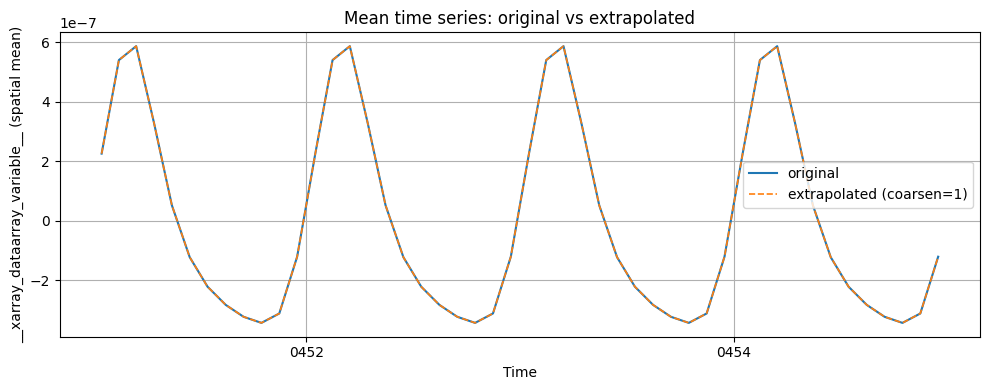

In [5]:
# Plot mean time-series for original and extrapolated datasets
# Determine time coordinate and dimension names
time_dim = ds[varname].dims[0]
try:
    time_coord = ds.coords[time_dim]
except Exception:
    time_coord = np.arange(arr.shape[0])

# Compute mean over spatial dims
spatial_dims = [d for d in ds[varname].dims if d != time_dim]
orig_ts = ds[varname].mean(dim=spatial_dims)
ex_ts = ds_ex[varname].mean(dim=spatial_dims)

plt.figure(figsize=(10, 4))
#plt.plot(time_coord, orig_ts, label='original', linewidth=1.5)
#plt.plot(time_coord, ex_ts, label=f'extrapolated (coarsen={coarsen})', linewidth=1.2, linestyle='--')
orig_ts.plot(label='original', linewidth=1.5)
ex_ts.plot(label=f'extrapolated (coarsen={coarsen})', linewidth=1.2, linestyle='--')
plt.xlabel(time_dim)
plt.ylabel(f'{varname} (spatial mean)')
plt.title('Mean time series: original vs extrapolated')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

**Run instructions:**

1. Open this notebook in VS Code or Jupyter and run the cells in order.
2. If `DIR_PROCESSED` is not defined, set it in a new cell, for example:

```python
DIR_PROCESSED = '/path/to/processed'
```

3. To speed up prototyping, set `coarsen = 2` (or 4) in the first code cell before running the extrapolation cell.
4. If you want the extrapolated results saved to disk, add `ds_ex.to_netcdf(...)` after the extrapolation cell.

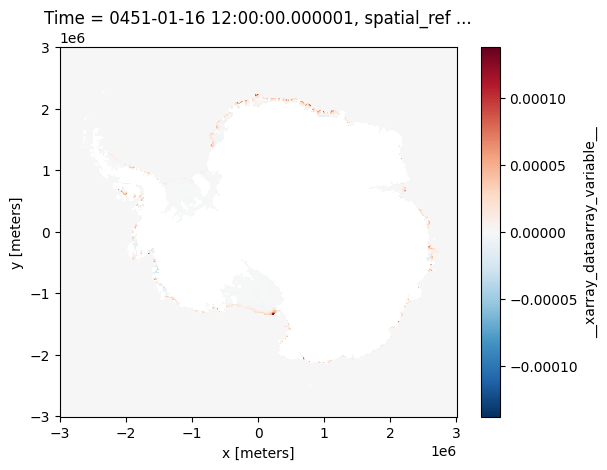

In [8]:
ds.__xarray_dataarray_variable__[0].plot()

In [14]:
# Plot time series at a selected pixel location in `ds` and `ds_ex`
# By default this uses a randomly chosen valid pixel (non-NaN and non-zero temporal mean).
# You may override by defining `PIX_Y` and `PIX_X` before running this cell (integer indices).
import numpy as np
import matplotlib.pyplot as plt

# Determine variable and time/spatial dims
try:
    var = varname
except NameError:
    var = list(ds.data_vars)[0]

time_dim = ds[var].dims[0]
spatial_dims = [d for d in ds[var].dims if d != time_dim]
if len(spatial_dims) != 2:
    raise RuntimeError('Expected two spatial dimensions (y,x) in the dataset)')

y_dim, x_dim = spatial_dims

# If PIX_Y / PIX_X are not provided, pick a random valid pixel where the temporal mean is finite and not zero
data = ds[var].values  # shape (time, y, x)
# compute temporal mean ignoring NaNs
with np.errstate(all='ignore'):
    temporal_mean = np.nanmean(data, axis=0)
valid_mask = np.isfinite(temporal_mean) & (temporal_mean != 0)
valid_indices = np.argwhere(valid_mask)
if valid_indices.size == 0:
    # fallback to center pixel
    iy_default = ds.sizes[y_dim] // 2
    ix_default = ds.sizes[x_dim] // 2
    PIX_Y = globals().get('PIX_Y', iy_default)
    PIX_X = globals().get('PIX_X', ix_default)
    print('No valid non-zero pixels found; using center pixel indices:', PIX_Y, PIX_X)
else:
    rng = np.random.default_rng()
    choice = rng.integers(0, valid_indices.shape[0])
    PIX_Y, PIX_X = int(valid_indices[choice, 0]), int(valid_indices[choice, 1])
    print(f'Randomly selected pixel indices PIX_Y={PIX_Y}, PIX_X={PIX_X}')

# Extract coordinate values if available
coord_info = ''
try:
    y_coord = ds.coords[y_dim].values[PIX_Y]
    x_coord = ds.coords[x_dim].values[PIX_X]
    coord_info = f"({y_dim}={y_coord}, {x_dim}={x_coord})"
except Exception:
    coord_info = f"({y_dim}_idx={PIX_Y}, {x_dim}_idx={PIX_X})"

# Extract time coordinate
if time_dim in ds.coords:
    time_coord = ds.coords[time_dim]
else:
    time_coord = np.arange(ds[var].shape[0])

# Extract pixel time series
orig_ts = ds[var].isel({y_dim: PIX_Y, x_dim: PIX_X}).values
ex_ts = ds_ex[var].isel({y_dim: PIX_Y, x_dim: PIX_X}).values



Randomly selected pixel indices PIX_Y=377, PIX_X=176


/var/folders/6z/tqg0lf9108s22svs6qbs4d_80131yc/T/ipykernel_24951/3506800002.py:24: RuntimeWarning: Mean of empty slice
  temporal_mean = np.nanmean(data, axis=0)


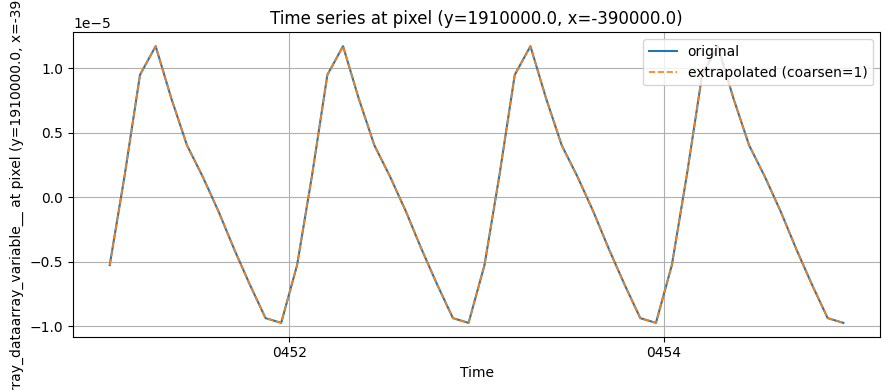

In [17]:
choice = rng.integers(0, valid_indices.shape[0])
PIX_Y, PIX_X = int(valid_indices[choice, 0]), int(valid_indices[choice, 1])
coord_info = ''
try:
    y_coord = ds.coords[y_dim].values[PIX_Y]
    x_coord = ds.coords[x_dim].values[PIX_X]
    coord_info = f"({y_dim}={y_coord}, {x_dim}={x_coord})"
except Exception:
    coord_info = f"({y_dim}_idx={PIX_Y}, {x_dim}_idx={PIX_X})"

# Extract time coordinate
if time_dim in ds.coords:
    time_coord = ds.coords[time_dim]
else:
    time_coord = np.arange(ds[var].shape[0])

# Extract pixel time series
orig_ts = ds[var].isel({y_dim: PIX_Y, x_dim: PIX_X})
ex_ts = ds_ex[var].isel({y_dim: PIX_Y, x_dim: PIX_X})


# Plot
plt.figure(figsize=(9, 4))
#plt.plot(time_coord, orig_ts, label='original', linewidth=1.5)
#plt.plot(time_coord, ex_ts, label=f'extrapolated (coarsen={coarsen})', linewidth=1.2, linestyle='--')
orig_ts.plot(label='original', linewidth=1.5)
ex_ts.plot(label=f'extrapolated (coarsen={coarsen})', linewidth=1.2, linestyle='--')
plt.xlabel(time_dim)
plt.ylabel(f'{var} at pixel {coord_info}')
plt.title(f'Time series at pixel {coord_info}')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

